### 🗂️ PROYECTO INTEGRADOR MODULO 4 - AVANCE 3

**BREVE RESUMEN**
Tenemos nuestro socio FinanceGuard, quien es un banco digital que ha experimentado un crecimiento exponencial en los últimos años, alcanzando  10000 clientes activos. Sin embargo, la dirección ha detectado un incremento preocupante en la tasa de abandono de clientes (churn), que actualmente alcanza el 20% anual, resultando en pérdidas millonarias. 
Para revertir esta situación, la compañía busca aprovechar el potencial del análisis de datos y el aprendizaje automático. Para el desarrollo de un sistema predictivo que identifique a los clientes con mayor probabilidad de abandonar la entidad, facilitando estrategias de retención más efectivas.

### 🔎 CONTEXTO DE NUESTROS OBJETIVOS PARA ESTE AVANCE
Aplicarremos técnicas de clustering y reducción de dimensionalidad para descubrir patrones ocultos en los datos de los clientes. A través de estas técnicas, identificaremos segmentos con comportamientos diferenciados y analizaremos su relación con la tasa de churn, aportando una visión complementaria a los modelos supervisados desarrollados previamente. Esto se realizará a través de modelos de aprendizajes NO supervisados. 

**Avance 3 - Modelos de aprendizajes No Supervisados, uso de K-Means, DBSCAN, PCA, t-SNE, Aplicación al problema de churn.**

**Terminos:**
- Aprendizaje No Supervisado: consiste en encontrar una estructura en datos SIN etiquetas (sin variable objetivo), a través de agrupamientos según la distancia y/o similitudes de los datos, (K - vecinos), usando una medición y/o distancia, tales como:
    1. Euclidiana: la distancia en línea recta entre dos puntos en un espacio plano
    2. Manhattan: es la suma de las diferencias absolutas de las variables, sin elevarlas al cuadrado. Una de las mediciones más robusta que la distancia Euclidiana, ya que su funcionalidad aplica cuando los datos tienen valores atípicos (outliers)
    3. Coseno: no mide qué tan separados están dos puntos en el espacio, sino el ángulo que forman desde el origen. Si el ángulo es 0 grados, significa que apuntan exactamente en la misma dirección (máxima similitud)
    4. Mahalanobis: aplica más para datos correlacionados. Es una versión avanzada de la distancia euclidiana que tiene en cuenta cómo varían las columnas entre sí y la correlación que hay entre ellas
    5. Jaccard: aplica más para variables binarias. Mide la proporción de características que dos registros comparten en comparación con el total de características que tienen
    
- K-Means: algoritmo de clustering que divide datos en K grupos minimizando la distancia al centroide (punto medio - promedio de todos los puntos en un cluster)
- DBSCAN: Density-Based Spatial Clustering, encargado de agrupar por densidad, detecta outliers automáticamente
- PCA: Principal Component Analysis, es la proyección lineal que maximiza varianza explicada (% de variabilidad total retenida por cada componente)
- t-SNE: t-Distributed Stochastic Neighbor Embedding, esproyección no lineal para visualización 2D/3D

**Métricas de Evaluación:**
- Elbow method: método del codo, consiste en graficar SSE vs K para encontrar el "codo" donde la mejora se estanca. Se lee de ascendente a descendente. Nos permite reconocer la cantidad ideal de "k" (cluster), con la que podemos trabajar en el modelo.
- Silhouette: medida de coeficiente (-1 a 1), que nos indica qué tan bien cada punto pertenece a su cluster vs vecinos. Se sugiere realizarla al mismo tiempo que el método del codo, ya que la lectura seria: 
> El mejor -k- ubicado en la grafica del método del codo, y el mejor coeficiente (él mas alto) ubicado en la grafica de silueta (el más cercano a 1)


### ▶️ COMENZANDO AVANCE 3

### 🚀 IMPORTACIÓN DE LIBRERIAS


In [3]:
# Liberías base para manejo de Dataframe, calculos matematicos con Numpy, Graficas con seabornd y matplotlib.

import pandas as pd                     # Para manejo y limpieza de los DataFrame (el Dataset)
import numpy as np                      # Para realización de formulas matematicas
import seaborn as sns                   # Para mayor defición de mis graficas realizadas con Matplotlib
import matplotlib.pyplot as plt         # Para creación de graficas estructuradas con diferentes estilos
import warnings                         # Para la cancelación de mensajes de errores en la generación de graficas
#import optuna                           # Optuna para optimización bayesiana (opcional)

# Para ignorar mensajes de "warning" en la realización de laas graficas
warnings.filterwarnings('ignore') 

# Para mejor visualización del Dataset descargado en el DataFrame
from IPython.display import display     

# Para escalar valores numericos y convertir valores categoricos a numeros o a BOOL
# Útil para la preparación de los datos antes de entrenar el modelo
from sklearn.preprocessing import StandardScaler      # Para escalar valores numericas
from sklearn.preprocessing import LabelEncoder        # Para convertir valores categoricos a numeros o a BOOL

# Para la creación de modelos de Machine Learning supervisados y no supervisados
from sklearn.cluster import KMeans, DBSCAN # Clustering
from sklearn.metrics import silhouette_score, silhouette_samples # Métricas modelos No supervisados

# Reducción de dimensionalidad - Necesario para la visualización de los datos en 2D o 3D en modelos no supervisados
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configuación base de mis graficos
plt.style.use('seaborn-v0_8-whitegrid')   # Cuadrícula sutil de fondo
plt.rcParams.update({
    'figure.figsize': (10, 6),            # Tamaño estándar 
    'axes.titlesize': 14,                 # Tamaño de los titulos
    'axes.titleweight': 'bold',           # Titulos en negritas
    'axes.titlepad': 15                   # Ubicación del titulo para mayor visualización de la gráfica
})

# Selecciones del colores para las graficas
colors = ["#1B365D", "#4A90E2", "#95A5A6", "#9E1B32", "#E06666"]
sns.set_palette(sns.color_palette(colors))

# Configuración base de mi reproducibilidad para mis operaciones de numpy (sugerencia para manejar la misma semilla en la generación de números aleatorios)
np.random.seed(42)

print("Librerías descargadas con exito!🚀")

Librerías descargadas con exito!🚀


### 🔄️ CARGA DEL DATASET Y EDA

### ❗ INFORMACIÓN IMPORTANTE:
**Recordemos que para el Avance 2 exportamos nuestras Features y Target, tanto de entrenamiento como de validación en nuestro Avance 1 a varios archivos .CSV bajo los nombres (x_train_scaled - x_test_scaled - y_train - y_test). Para éste avance, se exporto el DataFrame final, codificado (sin escalar y con la columna "Exited") para el entrenamiento de nuestros modelos No Supervisados** 

**🔎 ESTADO DE MI DATASET**
- Dimensiones: filas total 10,000 -  columnas total 12.
- Tipo de datos: bool(2), float64(2), int64(8) - ✅ Confirmamos que si es posible escalar los datos.
- Datos NO escalados y aun cuenta con la columna "Exited", nuestra columna a predecir como tercera parte de este avance.
- ✅ Datos dentro del rango aceptado: no hay datos irracionales o extremos. El dataset se encuentra listo para trabajarlo.

In [4]:
# 1. Cargar datos preprocesados:
print(f"▶️ Realizando carga de mi Dataset preparado y codificado:...")

# 1.1 Cargar datos preprocesados y escalados:
df = pd.read_csv("../data/Churn_modelling_Encoder.csv")

# 2. Confirmando estado de mis datos:
print("\n🔴 OBSERVACIONES IMPORTANTES")
print(f"\nDimensiones de mi Dataset codificado:\nfilas: {df.shape[0]:,}, columnas: {df.shape[1]:,}\n")
print("-"*100)
print(f"\nTotal de valores únicos en nuestro Dataset: {df.nunique()}\n")
print("-"*100)
print(df.info())
print("-"*100)
display(df.head(10))
print("-"*100)
display(df.describe())

▶️ Realizando carga de mi Dataset preparado y codificado:...

🔴 OBSERVACIONES IMPORTANTES

Dimensiones de mi Dataset codificado:
filas: 10,000, columnas: 12

----------------------------------------------------------------------------------------------------

Total de valores únicos en nuestro Dataset: CreditScore           460
Gender                  2
Age                    70
Tenure                 11
Balance              6382
NumOfProducts           4
HasCrCard               2
IsActiveMember          2
EstimatedSalary      9999
Exited                  2
Geography_Germany       2
Geography_Spain         2
dtype: int64

----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             1000

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,1,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,1,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,0,False,False


----------------------------------------------------------------------------------------------------


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 💻 1. PREPARANDO DATOS PARA ENTRENAMIENTOS DE MODELOS

**Primemro deberemos eliminar de nuestro Dataset la columna a predecir ('Exited'), en este caso porque recordemos que en la tercera parte de éste avance, la integraremos nuevamente. Esto se realiza para evitar Data Leakage (Fuga de Datos).

Luego, realizaremos el escalado de nuestras features**

### 🎢 Datos del nuevo Dataset:
- Dimensiones: filas total 10,000 - columnas total 11
- Datos escalados correctamente
- 💪 Features finales: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']

**🚀 LISTO PARA ENTRENAR NUESTROS NUEVOS MODELOS!**

In [5]:
# 1. Eliminamos y/o separamos nuestra columna "Exited" para uso posterior
print("Extrayendo nuestra columna 'Exited' para uso posterior...")

X = df.drop('Exited', axis=1) # Variables predictoras (features)
y = df['Exited']              # Variable a predecir de uso posterior

print("Confimando dimensiones actuales de mi nuevo Dataset:")
print(f"filas: {X.shape[0]:,}, columnas: {X.shape[1]:,}")
print("-"*100)

# 2. Escalamos (paso CRUCIAL para K-Means y PCA) nuestras features para que tengan el mismo peso/importancia
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 3. Confirmamos que nuestros datos han sido escalados correctamente
print("🔴 OBSERVACIONES IMPORTANTES")
print(f"Estadísticas de las features escaladas:\n")
display(X_scaled.describe())
print("-"*100)
print("💪 Features finales:", list(X.columns))
print("-"*100)
print(f"\nDimensiones de mis features escaladas:\nfilas: {X_scaled.shape[0]:,}, columnas: {X_scaled.shape[1]:,}")

Extrayendo nuestra columna 'Exited' para uso posterior...
Confimando dimensiones actuales de mi nuevo Dataset:
filas: 10,000, columnas: 11
----------------------------------------------------------------------------------------------------
🔴 OBSERVACIONES IMPORTANTES
Estadísticas de las features escaladas:



,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,-4.856560e-16,1.236344e-16,2.316369e-16,-1.103118e-16,-6.536993e-17,1.421085e-17,6.394885e-18,-7.958079e-17,-2.522427e-17,1.598721e-17,-9.023893e-17
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-3.109504e+00,-1.095988e+00,-1.994969e+00,-1.733315e+00,-1.225848e+00,-9.115835e-01,-1.547768e+00,-1.030670e+00,-1.740268e+00,-5.787359e-01,-5.738092e-01
25%,-6.883586e-01,-1.095988e+00,-6.600185e-01,-6.959818e-01,-1.225848e+00,-9.115835e-01,-1.547768e+00,-1.030670e+00,-8.535935e-01,-5.787359e-01,-5.738092e-01
50%,1.522218e-02,9.124191e-01,-1.832505e-01,-4.425957e-03,3.319639e-01,-9.115835e-01,6.460917e-01,9.702426e-01,1.802807e-03,-5.787359e-01,-5.738092e-01
75%,6.981094e-01,9.124191e-01,4.842246e-01,6.871299e-01,8.199205e-01,8.077366e-01,6.460917e-01,9.702426e-01,8.572431e-01,1.727904e+00,-5.738092e-01
max,2.063884e+00,9.124191e-01,5.061197e+00,1.724464e+00,2.795323e+00,4.246377e+00,6.460917e-01,9.702426e-01,1.737200e+00,1.727904e+00,1.742740e+00


----------------------------------------------------------------------------------------------------
💪 Features finales: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
----------------------------------------------------------------------------------------------------

Dimensiones de mis features escaladas:
filas: 10,000, columnas: 11


### 💻 2. K-MEANS CLUSTERING - MÉTODO DEL CODO Y SILUETA

***Breve concepto*** 
Recordemos que el Método del Codo y Método Silueta, nos permite visualizar cual es la cantidad optima de K-Means para entrenar el modelo.
- SSE (WCSS): es la suma de Errores al Cuadrado. WCSS (Within-Cluster Sum of Squares) comparte el mismo concepto, mide qué tan compactos o apretados están los puntos dentro de cada grupo.
- Silhouette Score (Coeficiente de Silueta): mide qué tan bien separado está un grupo respecto a los demás (compara la distancia interna vs. la distancia al grupo más cercano). El calculo se realiza de -1 a 1, es decir:
1. Cercano a 1: El punto está muy bien agrupado y lejos de otros clusters.
2. Cercano a 0: El punto está en el límite entre dos clusters.
3. Negativo: El punto probablemente fue asignado al cluster equivocado.

### 📌 Selección del Número Óptimo de Clusters (K-Means)
Para determinar la cantidad idónea de segmentos (K), se evaluó el algoritmo K-Means en un rango de K [2, 10], analizando dos métricas fundamentales:

***1. Análisis de Métricas***
**Método del Codo (SSE / WCSS):** Muestra una caída pronunciada desde K=2 hasta K=3 (SSE = 88,349), donde la curva empieza a suavizar su pendiente. Esto indica que a partir de K=3 o K=4, la ganancia en la reducción del error intra-cluster comienza a estabilizarse.

**Coeficiente de Silueta (Silhouette Score):** Alcanza su **pico máximo global en K=3 (0.1334)**, seguido por una caída en K=4 (0.1174) y K=5 (0.1012). Esto confirma que con 3 agrupaciones los datos mantienen la mejor separación y cohesión relativa.

#### 📊 Comparativa de Candidatos Principales

| Número de Clusters (K) | Inercia (SSE / WCSS) | Coeficiente de Silueta |

- | **K = 3** | **88,349** | **0.1334** *(Máximo global)* |
- | **K = 4** | 82,586 | 0.1174 |
- | **K = 5** | 79,247 | 0.1012 |

#### 💡 Decisión
Se realizará el entrenamiento nuevamente pero tomando en cuenta los mejores 3 valores de K, previamente descritos, ésto con el fin de encontrar el K mejor experimentado


⏱️ Tiempo de ejecución para calcular SSE y Silhouette: 11.07 segundos


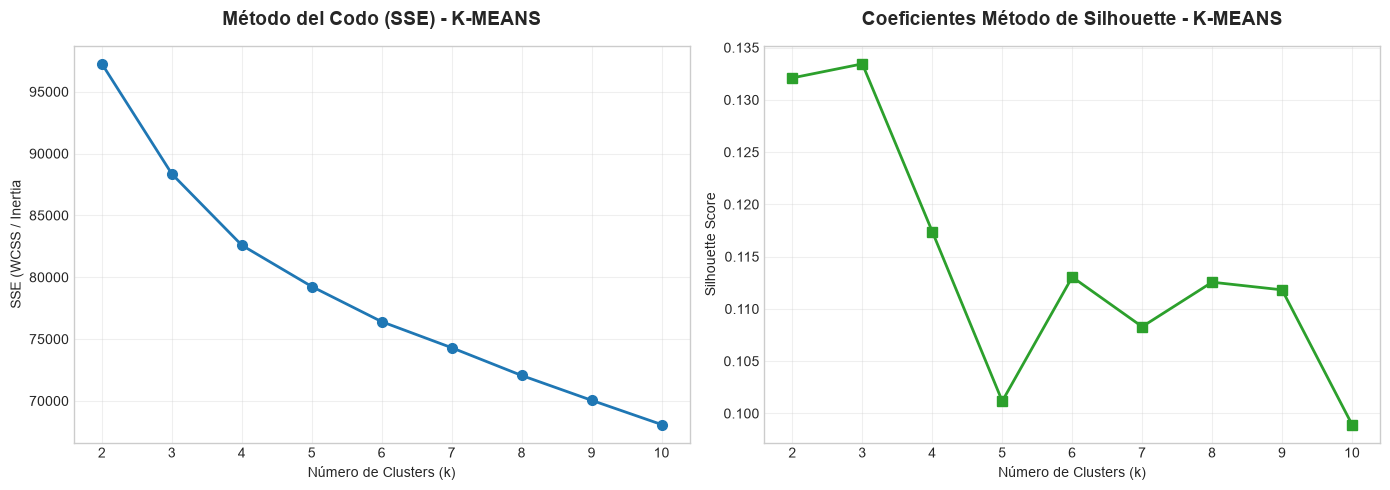

📋 RESUMEN DE MÉTRICAS POR NÚMERO DE CLUSTERS (K):
K =  2  |  SSE (WCSS):   97252.44  |  Silhouette Score: 0.1321
K =  3  |  SSE (WCSS):   88348.90  |  Silhouette Score: 0.1334
K =  4  |  SSE (WCSS):   82585.64  |  Silhouette Score: 0.1174
K =  5  |  SSE (WCSS):   79246.99  |  Silhouette Score: 0.1012
K =  6  |  SSE (WCSS):   76404.88  |  Silhouette Score: 0.1130
K =  7  |  SSE (WCSS):   74299.96  |  Silhouette Score: 0.1083
K =  8  |  SSE (WCSS):   72056.40  |  Silhouette Score: 0.1126
K =  9  |  SSE (WCSS):   70048.71  |  Silhouette Score: 0.1118
K = 10  |  SSE (WCSS):   68090.15  |  Silhouette Score: 0.0989
----------------------------------------------------------------------------------------------------
Mejores valores de K para el reporte final:
📊 Valores clave para seleccionar K (3, 4, 5):
   K=3: SSE=88349 | Silhouette=0.1334
   K=4: SSE=82586 | Silhouette=0.1174
   K=5: SSE=79247 | Silhouette=0.1012


In [6]:
# 1. Calculamos SSE (WCSS) y Silhouette
k_range = range(2, 11)  # Rango de k a evaluar

# 2. Inicializamos listas para almacenar SSE y Silhouette
sse_list = []  # Lista para almacenar SSE
silhouette_list = []  # Lista para almacenar Silhouette

# 3. Iteramos sobre el rango de k para calcular SSE y Silhouette (tambien capturo el tiempo de ejecución)
start_time = pd.Timestamp.now()  # Capturamos el tiempo de inicio

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # Inicializamos KMeans
    km.fit(X_scaled)  # Ajustamos el modelo a los datos escalados
    sse_list.append(km.inertia_)  # inertia_ atributo especifico de sk-learn Almacenamos, significa cuantos SSE dentro de clusters
    silhouette_list.append(silhouette_score(X_scaled, km.labels_)) # Calculamos y almacenamos Silhouette

end_time = pd.Timestamp.now()  # Capturamos el tiempo de finalización
execution_time = (end_time - start_time).total_seconds()  # Calculamos el tiempo
print(f"\n⏱️ Tiempo de ejecución para calcular SSE y Silhouette: {execution_time:.2f} segundos")

# 4. Graficamos métrica del codo y Silhouette para determinar el mejor número de clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4.1 Gráfica del Método del Codo (SSE)
axes[0].plot(k_range, sse_list, marker='o', color='#1f77b4', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo (SSE) - K-MEANS')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('SSE (WCSS / Inertia')
axes[0].set_xticks(k_range)
axes[0].grid(True, alpha=0.3)

# 4.2 Gráfica del Método de Silhouette
axes[1].plot(k_range, silhouette_list, marker='s', color='#2ca02c', linewidth=2, markersize=7)
axes[1].set_title('Coeficientes Método de Silhouette - K-MEANS')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

# 5. Imprimir resumen de valores para facilitar el análisis del reporte
print("📋 RESUMEN DE MÉTRICAS POR NÚMERO DE CLUSTERS (K):")
for k, sse, sil in zip(k_range, sse_list, silhouette_list):
    print(f"K = {k:2d}  |  SSE (WCSS): {sse:10.2f}  |  Silhouette Score: {sil:.4f}")
print("-" * 100)

# 6. Conclusión de los mejores valores de K para el reporte final
print("Mejores valores de K para el reporte final:") 
print("📊 Valores clave para seleccionar K (3, 4, 5):")
for k in [3, 4, 5]:
    idx = k - 2
    print(f"   K={k}: SSE={sse_list[idx]:.0f} | Silhouette={silhouette_list[idx]:.4f}")

### 💻 2.1 K-MEANS CON [3, 4, 5] - Selección de K Óptimo

Se entrenaron las mejores tres (3) variantes del algoritmo **K-Means** evaluado anteriormente, para seleccionar el valor de K más optimo para nuestro modelo:

#### 📊 Resultados de la Evaluación

1. **Modelo $K = 3$:**
   * **Silhouette Score:** `0.1334` *(Mayor valor del experimento)*
   * **Distribución de Clientes:** `[2509, 5014, 2477]`
   * **Comentario:** Presenta grupos robustos, representativos y bien balanceados (primer grupo: aprox 25%, segundo grupo: aprox 50%, y tercer grupo: aprox 25%).

2. **Modelo $K = 4$:**
   * **Silhouette Score:** `0.1174`
   * **Distribución de Clientes:** `[2509, 2399, 2477, 2615]`
   * **Comentario:** Mantiene una buena proporción de tamaño, pero reduce la cohesión y separación entre clusters.

3. **Modelo $K = 5$:**
   * **Silhouette Score:** `0.1012`
   * **Distribución de Clientes:** `[2509, 1466, 1875, 1674, 2476]`
   * **Comentario:** Fragmenta los datos en segmentos más pequeños sin aportar una mejora en la calidad de separación.

#### ✅ Decisión Final
* **$K$ Seleccionado:** **`3`**
* **Justificación (*Data-Driven*):** Se selecciona **$K = 3$** de forma automatizada por presentar el mayor *Silhouette Score* (`0.1334`), garantizando la estructura con mayor separación matemática y la mejor segmentación utilizable para el negocio.

**Data-Driven:** se refiere a cuando el algoritmo agrupa, organiza o simplifica la información sin imponer ninguna regla, etiqueta o prejuicio humano previo.

In [7]:
# 1. Entrenamos el modelo con los mejores valores de K (3, 4, 5) y evaluamos su desempeño
print("Reentrenando para confirmar el mejor K y evaluar desempeño de los modelos entrenados...")
print("-"*100)

# 1.1 Tomando tiempo de ejecución para el entrenamiento de los modelos KMeans
start_time_k = pd.Timestamp.now()  # Capturamos el tiempo de inicio

k_values = [3, 4, 5]
kmeans_models = {}  # Diccionario para almacenar modelos KMeans entrenados

# 2. Iteramos sobre los valores de K para entrenar y almacenar los modelos
for k in k_values:
    km_v = KMeans(n_clusters=k, random_state=42, n_init=10)  # Inicializamos KMeans
    km_v.fit(X_scaled)  # Ajustamos el modelo a los datos escalados
    kmeans_models[k] = km_v  # Almacenamos el modelo entrenado en el diccionario
    sil = silhouette_score(X_scaled, km_v.labels_)  # Calculamos el Silhouette Score
    # Imprimimos el resumen de cada modelo entrenado. "Cluster:" es la cantidad de clientes que quedaron asignados a cada grupo
    print(f"Modelo KMeans entrenado K={k}: {km_v.n_clusters} clusters, Silhouette={sil:.4f}, tamaños: {np.bincount(km_v.labels_)}")

end_time_k = pd.Timestamp.now()  # Capturamos el tiempo de finalización
execution_time_k = (end_time_k - start_time_k).total_seconds()  # Calculamos el tiempo
print(f"\n⏱️ Tiempo de ejecución para entrenar modelos KMeans: {execution_time_k:.2f} segundos")

# 3. Usaremos K óptimo para el resto (basado en silhouette - verificamos cuál tiene mayor score)
best_k = max(k_values, key=lambda k: silhouette_score(X_scaled, kmeans_models[k].labels_))
print(f"\n✅ K óptimo por Silhouette: {best_k}")

# Calculamos el mejor k para el modelo y lo agregamos al DataFrame original para su posterior análisis
k_final = best_k
df['cluster_kmeans'] = kmeans_models[k_final].labels_

Reentrenando para confirmar el mejor K y evaluar desempeño de los modelos entrenados...
----------------------------------------------------------------------------------------------------
Modelo KMeans entrenado K=3: 3 clusters, Silhouette=0.1334, tamaños: [2509 5014 2477]
Modelo KMeans entrenado K=4: 4 clusters, Silhouette=0.1174, tamaños: [2509 2399 2477 2615]
Modelo KMeans entrenado K=5: 5 clusters, Silhouette=0.1012, tamaños: [2509 1466 1875 1674 2476]

⏱️ Tiempo de ejecución para entrenar modelos KMeans: 3.55 segundos

✅ K óptimo por Silhouette: 3


### 💻 2.2 INTERPRETACIÓN DE CENTROIDE

***BREVE CONCEPTO:***
* **Centroide:** Es el punto central (geométrico y matemático) que representa a todo un cluster. Se calcula como el valor promedio (media) de todas las características (*features*) de los clientes asignados a ese grupo específico. Representa al "cliente promedio" o perfil típico del grupo.
* **Iteraciones:** Es el proceso repetitivo mediante el cual K-Means ajusta los grupos. En cada iteración:
  1. Se asigna cada cliente al centroide más cercano (midiendo la distancia euclidiana).
  2. Se recalcula la posición del centroide tomando el nuevo promedio del grupo.
  3. El algoritmo repite este ciclo hasta que los centroides dejan de moverse (convergencia) o se alcanza el límite máximo de iteraciones.

**❗ Importante**
 Usamos scaler.inverse_transform para obtener valores en unidades originales (edad en años, balance en dólares, etc.), para mantener congruencias en los valores, sobre todo en las columnas que fueron codificadas con One Hot Encoding.

 #### 1. Centroides en Escala Original (Interpretación de Negocio)
Al des-escalar los centroides a sus unidades reales (dólares, años, proporciones 0-1), obtenemos los perfiles claros de los tres segmentos de clientes:

| Variable | Cluster 0 (Alemania) | Cluster 1 (Francia) | Cluster 2 (España) |

- | **CreditScore** | 651.45 |           649.67 |               651.33 |
- | **Gender (Hombres %)** | 52% |          55% |                  56% |
- | **Age (Edad Promedio)** | 39.77 años | 38.51 años | 38.89 años |
- | **Tenure (Antigüedad)** | 5.01 años | 5.00 años | 5.03 años |
- | **Balance (Saldo Promedio)** | **$119,730.12** | **$62,092.64** | **$61,818.15** |
- | **NumOfProducts** | 1.52 | 1.53 | 1.54 |
- | **HasCrCard (% Tarjeta)** | 71% | 71% | 69% |
- | **IsActiveMember (% Activos)** | 50% | 52% | 53% |
- | **EstimatedSalary** | $101,113.44 | $99,899.18 | $99,440.57 |
- | **Geography_Germany** | **1.0 (100%)** | 0.0 (0%) | 0.0 (0%)|
- | **Geography_Spain** | 0.0 (0%) | 0.0 (0%) | **1.0 (100%)** |

#### 💡 Resumen del Perfil de los Clusters

1. **Cluster 0 — "Clientes de Alto Valor / Alemania":** 
   * Representa al 100% de la base de clientes ubicada en **Alemania**.
   * Tienen el **saldo promedio en cuenta más elevado** de la institución (119,730.12 vs. aprox 62,000 de los otros grupos).
   * Edad promedio ligeramente mayor (39.8 años) y salarios altos (101,113.44).

2. **Cluster 1 — "Base Clientes Francia":** 
   * Representa a la base de clientes ubicada en **Francia** (5,014 clientes, el grupo/cluster más numeroso con aprox 50% del total).
   * Mantienen un saldo promedio moderado de 62,092.64.

3. **Cluster 2 — "Base Clientes España":** 
   * Representa al 100% de la base de clientes ubicada en **España**.
   * Su perfil financiero (saldo de 61,818.15, salario de 99,440.57 y tenencia de productos) es prácticamente idéntico al de los clientes de Francia, pero diferenciado geográficamente.

#### 2. Centroides en Escala Estandarizada
En la escala estandarizada (donde la media es 0 y la desviación estándar es 1), observamos directamente qué variables determinaron la separación de los clusters (peso):

* **Separación por Geografía:** 
  1. * El **Cluster 0** presenta un Z-score muy alto en `Geography_Germany` (positive 1.7279), mientras que los demás son negativos (-0.5787).
  2. * El **Cluster 2** presenta un Z-score muy alto en `Geography_Spain` (positive +1.7427$), mientras que los demás son negativos (-0.5738).
  3. * El **Cluster 1** tiene valores negativos en ambas variables geográficas, lo que implica que agrupa a los clientes de la tercera categoría de origen (Francia).

* **Diferencia en Saldo (`Balance`):** 
  * El **Cluster 0** destaca con un Z-score positivo en el saldo disponible (+0.6931), a diferencia de los Clusters 1 y 2 que muestran saldos por debajo de la media (-0.2307 y -0.2351).

> **Conclusión Estandarizada:** El modelo K-Means se basó fuertemente en la **ubicación geográfica** y el **nivel de saldo en cuenta** para crear las 3 divisiones principales.

In [8]:
# 1. Visualizamos la distribución de los clusters en el DataFrame original
display(df.head(10))
print("Se confirma columna en nuestro DataFrame original con los clusters asignados correctamente.")
print("-"*100)

# 1. Centroides en escala estandarizada
centroids_scaled = kmeans_models[k_final].cluster_centers_
centroids_scaled_df = pd.DataFrame(centroids_scaled, columns=X.columns)
centroids_scaled_df.insert(0, 'Cluster', range(k_final))

print("📌 CENTROIDES EN ESCALA ESTANDARIZADA:")
display(centroids_scaled_df.round(4))
print("-"*100)

# 2. Centroides des-escalados a su escala original (Recomendado en este caso por tener columnas con one encoding
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_orig_df = pd.DataFrame(centroids_original, columns=X.columns)
centroids_orig_df.insert(0, 'Cluster', range(k_final))

print("\n📌 CENTROIDES EN ESCALA ORIGINAL (INTERPRETABLES):")
display(centroids_orig_df.round(2))

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,cluster_kmeans
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True,2
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False,1
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False,1
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True,2
5,645,1,44,8,113755.78,2,1,0,149756.71,1,False,True,2
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False,1
7,376,0,29,4,115046.74,4,1,0,119346.88,1,True,False,0
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False,1
9,684,1,27,2,134603.88,1,1,1,71725.73,0,False,False,1


Se confirma columna en nuestro DataFrame original con los clusters asignados correctamente.
----------------------------------------------------------------------------------------------------
📌 CENTROIDES EN ESCALA ESTANDARIZADA:


,Cluster,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,0,0.0096,-0.0426,0.0810,-0.0010,0.6931,-0.0180,0.0183,-0.0354,0.0178,1.7279,-0.5738
1,1,-0.0089,0.0068,-0.0391,-0.0028,-0.2307,0.0012,0.0025,0.0033,-0.0033,-0.5787,-0.5738
2,2,0.0083,0.0294,-0.0029,0.0067,-0.2351,0.0158,-0.0235,0.0292,-0.0113,-0.5787,1.7427


----------------------------------------------------------------------------------------------------

📌 CENTROIDES EN ESCALA ORIGINAL (INTERPRETABLES):


,Cluster,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,0,651.45,0.52,39.77,5.01,119730.12,1.52,0.71,0.50,101113.44,1.0,0.0
1,1,649.67,0.55,38.51,5.00,62092.64,1.53,0.71,0.52,99899.18,-0.0,-0.0
2,2,651.33,0.56,38.89,5.03,61818.15,1.54,0.69,0.53,99440.57,-0.0,1.0


### 💻 3. DBSCAN - (Density-Based clustering)

**Breve Concepto**
DBSCAN es un algoritmo de aprendizaje no supervisado basado en **densidad**. Agrupa puntos que están cercanamente agrupados en el espacio de características e identifica puntos aislados en regiones de baja densidad como ruido (*outliers*).

#### 1. Conceptos Clave de Clasificación de Puntos
DBSCAN clasifica cada dato de la muestra en una de tres categorías según la densidad local:

1. **Core Points (Puntos Núcleo):** Un punto es "Núcleo" si dentro de un radio de distancia especificado ("eps") tiene al menos un número mínimo de vecinos (min\_samples). **Representan el corazón denso de un cluster.**
2. **Border Points (Puntos Borde):** No cumplen con el número mínimo de vecinos para ser un punto núcleo, pero caen dentro del radio ("eps") de algún punto núcleo. **Pertenecen al cluster pero están en sus periferias.**
3. **Noise / Outliers (Ruido o Valores Atípicos):** Puntos que no son ni núcleos ni bordes. No tienen suficiente densidad a su alrededor ni están cerca de un centro denso. **DBSCAN les asigna la etiqueta `-1`.**

#### 2. Parámetros Básicos
A diferencia de K-Means, DBSCAN no requiere definir la cantidad de clusters, sino dos parámetros hiperespaciales:

1. **`eps` (Epsilon):** Es el radio máximo de distancia entre dos puntos para considerarlos "vecinos". Si es muy pequeño, casi todo se considerará ruido; si es muy grande, todos los puntos se unirán en un solo gran cluster.
2. **`min_samples`:** El número mínimo de puntos (vecinos) requeridos dentro del radio ("eps") para que un punto se convierta en *Core Point*.

#### 3. Principales Ventajas de DBSCAN
1. **Detección Automática de Outliers:** Identifica y aisla activamente observaciones atípicas o ruidosas sin forzarlas a pertenecer a un grupo.
2. **No necesita definir K** El algoritmo descubre de manera autónoma el número natural de clusters presentes en los datos según la densidad.
3. **Formas Arbitrarias:** Puede encontrar clusters de cualquier forma geométrica (curvas, anillos, formas no esféricas), a diferencia de K-Means que solo circulos o esferas.

#### 4. Comparación: K-Means vs. DBSCAN
- K-Means
| **Criterio de Agrupación:** Distancia a un centroide (*Centroide-based*).
| **Número de Clusters (K):** Requiere definir $K$ manualmente antes de entrenar.
| **Manejo de Outliers:** Sensible a outliers (los fuerza a un cluster).
| **Forma de los Clusters:** Asume clusters esféricos / circulares.
| **Parámetros a Ajustar:** K (número de clusters).

- DBSCAN
**Criterio de Agrupación:** Densidad en el espacio (*Density-based*).
**Número de Clusters (K):** Descubre el número de clusters automáticamente.
**Manejo de Outliers:**  Robusto (los detecta como ruido / etiqueta `-1`).
**Forma de los Clusters:** Encuentra clusters de cualquier forma geométrica.
**Parámetros a Ajustar:** `eps` (radio) y `min_samples` (densidad).

### ⚙️ Resultados de la Ejecución de DBSCAN
Al ejecutar el algoritmo DBSCAN con los parámetros base ("eps" = 0.5, "min\_samples" = 5), se obtuvieron los siguientes resultados:

* **Clusters Válidos Encontrados:** `14`
* **Puntos Clasificados como Ruido / Outliers (`label=-1`):** `9,921`
* **Porcentaje de Ruido:** `99.21%`
* **Distribución de Clientes por Cluster:** `[7, 7, 5, 5, 7, 7, 6, 5, 5, 5, 5, 5, 5, 5]`

#### 🔍 Interpretación y Diagnóstico Técnico

1. **Efecto de Alta Dimensionalidad:** 
   Al contar con múltiples variables de distintos tipos (continuas y binarias One-Hot), el espacio de características es muy disperso. Un radio de vecindad de eps = 0.5$ resulta demasiado estricto, provocando que la inmensa mayoría de las observaciones (99.21) no alcancen la densidad mínima de 5 vecinos.

2. **Micro-clusters:** 
   Los 14 clusters identificados son extremadamente pequeños (de tan solo 5 a 7 clientes cada uno), lo cual no representa grupos o segmentos de negocio utilizables para tomar decisiones estratégicas.

#### ⚖️ Comparación Directa: K-Means vs. DBSCAN en este Dataset
* **K-Means:** logró segmentar el 100% de los clientes en el Dataset en **3 grupos claros, y representativos** (25%, 50% y 25%), tomando como peso variables geográficas y financieras.
* **DBSCAN:** Presenta limitaciones severas bajo la configuración estándar debido a la dispersión en el espacio de alta dimensión, requiriendo una afinación profunda de eps (o reducción previa de dimensiones como PCA) para ser funcional.

In [9]:
#1. Definimos los parametros a utilizar en DBSCAN. Para datos escalados el eps 0.3-1.0 y min_samples = 2*dim o 5
db = DBSCAN(eps=0.5, min_samples=5)
db.fit(X_scaled)
labels_db = db.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0) # Calcula el número real de clusters de forma limpia y evita contar el ruido con (-1)
n_noise = (labels_db == -1).sum() # Calcula el número de puntos de ruido (outliers) en el dataset

# 2. Imprimimos datos del modelo
print("Resultados DBSCAN")
print("-" * 100)
print(f"Clusters generados por DBSCAN: {n_clusters_db}")
print(f"Outliers (ruido, label=-1): {n_noise}") 
print(f"Porcentaje relativo: {n_noise/len(labels_db)*100:.2f}%")
print(f"Distribución por cluster: {np.bincount(labels_db[labels_db >= 0]) if n_clusters_db > 0 else 'N/A'}")

# 3. Agregamos los labels de DBSCAN al DataFrame original para su posterior análisis
df['cluster_dbscan'] = labels_db

# 4. Visualizamos la distribución de los clusters en el DataFrame original
display(df.head(10))

Resultados DBSCAN
----------------------------------------------------------------------------------------------------
Clusters generados por DBSCAN: 14
Outliers (ruido, label=-1): 9921
Porcentaje relativo: 99.21%
Distribución por cluster: [7 7 5 5 7 7 6 5 5 5 5 5 5 5]


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,cluster_kmeans,cluster_dbscan
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False,1,-1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True,2,-1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False,1,-1
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False,1,-1
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True,2,-1
5,645,1,44,8,113755.78,2,1,0,149756.71,1,False,True,2,-1
6,822,1,50,7,0.00,2,1,1,10062.80,0,False,False,1,-1
7,376,0,29,4,115046.74,4,1,0,119346.88,1,True,False,0,-1
8,501,1,44,4,142051.07,2,0,1,74940.50,0,False,False,1,-1
9,684,1,27,2,134603.88,1,1,1,71725.73,0,False,False,1,-1


### 💻 3.1 DBSCAN - Comparación Perfil de Outliers vs. Resto

**Breve Resumen**
Dado que DBSCAN separa los datos en dos grandes grupos:
- Outliers: Puntos aislados/ruido que recibieron la etiqueta cluster_dbscan == -1.
- Resto (Inliers): Puntos normales que sí quedaron dentro de un cluster (cluster_dbscan != -1).

### 📊 Comparativa de Perfiles: Outliers vs. Resto de Clientes
El análisis comparativo entre el grupo de **Outliers** (clientes aislados por baja densidad, `label=-1`) y el grupo **Resto** (clientes que formaron clusters densos) revela patrones de negocio fundamentales:

#### 💡 Principales Hallazgos y Diferencias Clave

1. **Saldo en Cuenta (`Balance`):** 
   * **Outliers:** Tienen un saldo promedio significativo de **$77,094.94**.
   * **Resto:** Su saldo promedio es de **$0.00**. 
   * *Diagnóstico:* La presencia o ausencia de capital en la cuenta fue el factor determinante para que DBSCAN catalogara a un cliente como "atípico".

2. **Riesgo de Fuga / Churn (`Exited`):** 
   * **Outliers:** Muestran una tasa de abandono del **21%** (`0.21`).
   * **Resto:** Presentan una tasa de abandono de apenas el **3%** (`0.03`).
   * *Importante:* al algoritmo no le entrenamos con datos de los clientes Churn. Sin embargo, solo analizando sus patrones intrínsecos de saldo y comportamiento, el algoritmo descubrió de forma natural un subgrupo de clientes que resulta tener un riesgo de abandono 7 veces mayor (21% vs 3%). 

3. **Composición Geográfica:** 
   * **Outliers:** Tienen presencia distribuida (25% Alemania, 25% España y 50% Francia).
   * **Resto:** Muestra **0% en Alemania y España**, lo que indica que el grupo "Resto" está compuesto exclusivamente por clientes de **Francia con saldo cero**.

4. **Adopción de Productos Financieros:** 
   * En el grupo **Resto**, el **100%** de los clientes cuenta con tarjeta de crédito (`HasCrCard = 1.00`) y consumen exactamente **2 productos** en promedio (`NumOfProducts = 2.00`).


In [10]:
# 1. Crear una columna condicional para identificar si es Outlier o Resto
df_copy = df.copy()  # Creamos una copia del DataFrame original para preservar los datos
df_copy['tipo_cliente'] = df_copy['cluster_dbscan'].apply(lambda x: 'Outliers' if x == -1 else 'Resto')

# 2. Calcular el promedio agrupando por ese tipo de cliente y trasponer (.T) la tabla
perfil_outliers = df_copy.groupby('tipo_cliente').mean(numeric_only=True).round(2).T

# 3. Reordenar las columnas para que salga "Outliers" primero y luego "Resto"
perfil_outliers = perfil_outliers[['Outliers', 'Resto']]

# 4. Mostrar la tabla resultante
print("Perfil de OUTLIERS (promedio) vs RESTO:")
display(perfil_outliers)

Perfil de OUTLIERS (promedio) vs RESTO:


tipo_cliente,Outliers,Resto
CreditScore,650.49,655.01
Gender,0.54,0.72
Age,38.95,35.19
Tenure,5.01,5.27
Balance,77094.94,0.00
NumOfProducts,1.53,2.00
HasCrCard,0.70,1.00
IsActiveMember,0.52,0.46
EstimatedSalary,100129.88,95112.52
Exited,0.21,0.03


### 💻 4. PCA - Reducción de Dimensionalidad

**Breve concepto** 
Es una técnica lineal no supervisada que transforma un conjunto de variables correlacionadas en un nuevo conjunto de variables no correlacionadas llamadas Componentes Principales (PC).

- Componentes Principales: Son combinaciones lineales de las columnas originales.
- El primer componente (PC1) se construye en la dirección donde los datos tienen la máxima variabilidad (información).
- El segundo componente (PC2) captura la siguiente mayor cantidad de varianza en una dirección perpendicular (ortogonal) a PC1, y así sucesivamente.

**Varianza**
- Varianza Explicada Individual: Indica qué porcentaje de la información total del dataset retiene un componente específico (ej. PC1 explica el 35% de la varianza).
- Varianza Explicada Acumulada: Es la suma progresiva de las varianzas explicadas de cada componente. Nos indica cuánta información preservamos al seleccionar N(número) componentes.

### 📉 Análisis de Varianza Explicada (PCA)
El análisis de componentes principales (PCA) aplicado sobre las 11 características del dataset muestra cómo se distribuye la información a lo largo de las dimensiones sintéticas:

#### 💡 Puntos Clave de Interpretación

1. **Baja Concentración en los Primeros Componentes:**
   * El primer componente (**PC1**) explica únicamente alrededor del **15%** de la varianza total.
   * Al combinar los dos primeros componentes (**PC1 + PC2**), la varianza acumulada alcanza solo el **25.37%**.
   * *Diagnóstico:* Las variables originales no están altamente correlacionadas linealmente entre sí. La información está bastante dispersa a lo largo de casi todas las dimensiones.

2. **Criterios de Selección de Componentes:**
   * **Criterio del 80%:** Se requieren **8 componentes principales** para conservar al menos el 80% de la varianza total de los datos.
   * **Criterio del 90%:** Se necesitan **10 componentes principales** para capturar el 90% de la información.

3. **Implicación para la Visualización en 2D:**
   * Debido a que PC1 y PC2 juntas solo conservan el **25.37%** de la información total, una proyección en un plano bidimensional (gráfico 2D) mostrará cierta superposición de puntos y no capturará toda la complejidad de los datos, lo cual es normal y esperado en datasets tabulares heterogéneos.

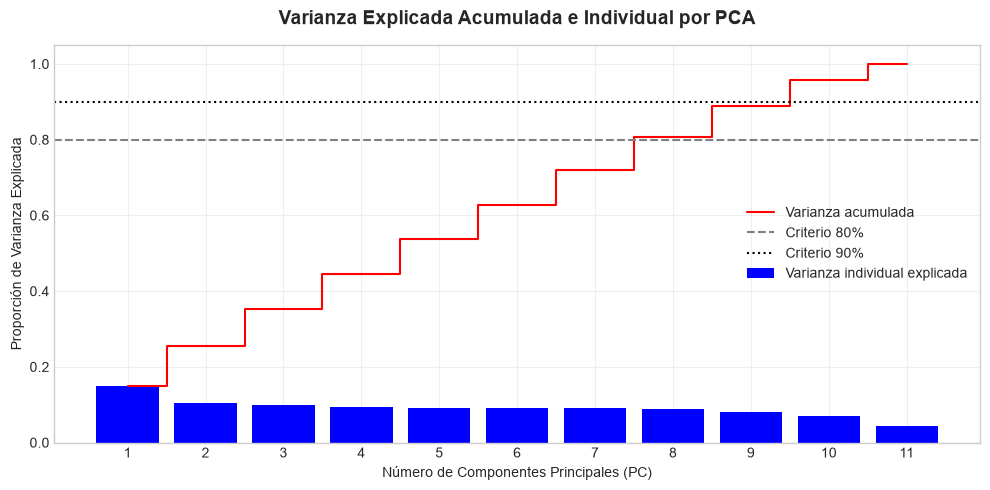

Componentes para 80% varianza: 8
Componentes para 90% varianza: 10
Varianza acumulada (2 componentes): 25.37%


In [11]:
# 1. Empleamos PCA con todos los componentes para ver varianza explicada
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# 2. Varianza explicada por componente
var_exp = pca_full.explained_variance_ratio_
var_exp_cum = np.cumsum(var_exp)

# 3. Graficamos la varianza individual y la varianza explicada acumulada
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(var_exp) + 1), var_exp, color='b', label='Varianza individual explicada')

# 3.1 Línea para la varianza acumulada
plt.step(range(1, len(var_exp_cum) + 1), var_exp_cum, where='mid', color='red', label='Varianza acumulada')

# 3.2 Líneas de referencia (80% y 90%)
plt.axhline(y=0.80, color='gray', linestyle='--', label='Criterio 80%')
plt.axhline(y=0.90, color='black', linestyle=':', label='Criterio 90%')

# 3.3 Configuración de ejes y títulos
plt.xlabel('Número de Componentes Principales (PC)')
plt.ylabel('Proporción de Varianza Explicada')
plt.title('Varianza Explicada Acumulada e Individual por PCA', fontsize=14, fontweight='bold')
plt.xticks(range(1, len(var_exp) + 1))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. N componentes que explican 80-90% varianza explicada. PCA 2
# Usamos el metodo searchsorted para encontrar el índice donde la varianza acumulada alcanza o supera el 80% y 90%
n_90 = np.searchsorted(var_exp_cum, 0.90) + 1
n_80 = np.searchsorted(var_exp_cum, 0.80) + 1
print(f"Componentes para 80% varianza: {n_80}")
print(f"Componentes para 90% varianza: {n_90}")
print(f"Varianza acumulada (2 componentes): {var_exp_cum[1]:.2%}")

### 💻 4.1 PCA - Reducción de Dimensionalidad (Proyección 2D)

### 📊 Descripción de la Proyección 2D (PCA)
* **Separación Clara:** Los 3 clusters de K-Means muestran una **transición continua y agrupamiento bien definido** a lo largo del eje **PC1** (de izquierda a derecha: Cluster 2 $\rightarrow$ Cluster 1 $\rightarrow$ Cluster 0).
* **Varianza Retenida:** El gráfico representa el **25.37%** de la información total (15.04% en PC1 + 10.33% en PC2), lo que explica la leve superposición en los bordes de los grupos.

VARIANZA INDIVIDUAL (PC1) Y VARIANZA EXPLICADA (PC2): [0.15042958 0.10330298]
Porcentaje de varianza explicada acumulada por 2 componentes: 25.37%


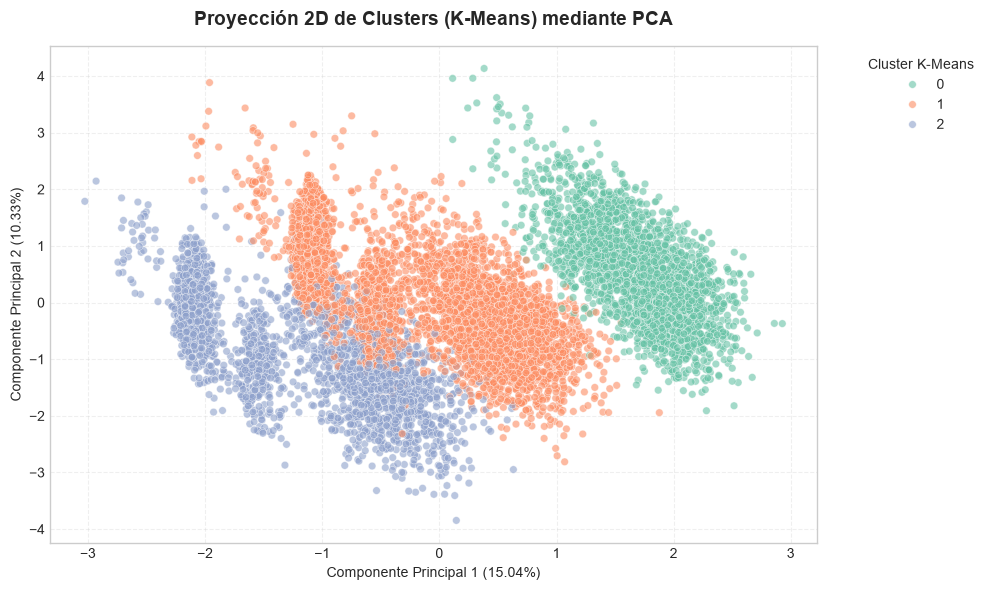

In [12]:
# 1. Definir parametros para la grafica 2D de nuestra varianza explicada por PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

# 2. Imprimimos la varianza explicada por cada componente principal
print("VARIANZA INDIVIDUAL (PC1) Y VARIANZA EXPLICADA (PC2):", pca_2d.explained_variance_ratio_)
sum_pca_2d = sum(pca_2d.explained_variance_ratio_)
print(f"Porcentaje de varianza explicada acumulada por 2 componentes: {sum_pca_2d * 100:.2f}%")

# 3. Creamos un DF para la visualización
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['cluster_kmeans'].values  # Asignamos los clusters de K-Means

# 3.1 Configuramos parametros para la visualización de los clusters en 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',     
    alpha=0.6,          
    s=30                
)
plt.title('Proyección 2D de Clusters (K-Means) mediante PCA', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Cluster K-Means', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 💻 5. t-SNE (t-Distributed Stochastic Neighbor Embedding) - Visualización No Lineal

***Breve Concepto***
El t-SNE Es una técnica no lineal de reducción de dimensionalidad enfocada exclusivamente en la visualización de datos complejos.
Convierte las afinidades (distancias) entre puntos de alta dimensión en probabilidades condicionales. Su objetivo principal es preservar las relaciones locales: si dos puntos están muy cerca en 11 dimensiones, t-SNE hará todo lo posible para que sigan estando muy cerca en el gráfico 2D.

- Parámetro perplexity: controla el balance entre la atención que el algoritmo le da a las relaciones locales (puntos muy cercanos) frente a las globales (la estructura general del mapa). Ejemplo:
1. Un perplexity bajo (ej. 5) se enfoca en micro-grupos muy reducidos.
2. Un perplexity alto (ej. 50) intenta capturar patrones más globales.

### Diferencias Clave entre PCA y t-SNE
- PCA (Principal Component Analysis)
 1. Tipo de Técnica: Lineal
 2. Enfoque Principal: Preservar la varianza global (distancias grandes).
 3. Reversibilidad / Uso: Permite proyectar nuevos datos (transform). Es útil para entrenar otros modelos.
 4. Velocidad / Cómputo: Muy rápido y liviano.

- t-SNE (t-SNE)
 1. Tipo de Técnica: No lineal
 2. Enfoque Principal: Preservar la estructura local (vecinos cercanos).
 3. Reversibilidad / Uso: Solo sirve para visualizar. No permite mapear datos nuevos directamente.
 4. Velocidad / Cómputo: Computacionalmente pesado y lento en grandes volúmenes de datos.

### ⚠️ Limitaciones y Cuidados en la Interpretación 
 1. Las distancias entre clusters no importan: La distancia visual entre dos grupos aislados en t-SNE no significa nada. Dos clusters que se ven lejanos en la gráfica no necesariamente están lejanos en los datos reales.
 2. El tamaño de los clusters es engañoso: t-SNE tiende a expandir los grupos densos y comprimir los grupos dispersos. Un cluster visualmente "más grande" no significa que tenga mayor varianza en los datos originales.
 3. Sensibilidad a la Semilla (random_state): Al ser un algoritmo estocástico (basado en probabilidades), diferentes corridas o semillas pueden generar formas visuales totalmente distintas, aunque los grupos sigan siendo los mismos.
 4. No preserva varianza: A diferencia de PCA, t-SNE no te da una métrica como "porcentaje de varianza explicada".

#### 💡 Principales Hallazgos e Interpretación
La proyección no lineal mediante t-SNE ofrece una perspectiva complementaria a PCA, enfocándose en preservar las relaciones de vecindad local entre los clientes:

1. **Separación de Fronteras Definida:** 
   **separación casi perfecta entre los 3 clusters de K-Means**.
   * El Cluster 2 (azul) se agrupa nítidamente hacia la izquierda, el Cluster 1 (naranja) ocupa la franja central, y el Cluster 0 (verde) se posiciona a la derecha.

2. **Formación de Sub-grupos (Estructura Local):** 
   * Dentro de cada cluster principal, t-SNE revela pequeñas "sub-comunidades" densas. Esto confirma la presencia de sub-patrones de comportamiento muy específicos dentro de cada segmento de clientes.

3. **Validación del Modelo K-Means:** 
   * La ausencia de mezcla de colores dentro de las regiones confirma de manera robusta que K-Means logró segmentar a la población en grupos con similitudes locales altamente coherentes.

Ejecutando t-SNE para reducción de dimensionalidad a 2D...

⏱️ Tiempo de ejecución para t-SNE: 21.57 segundos


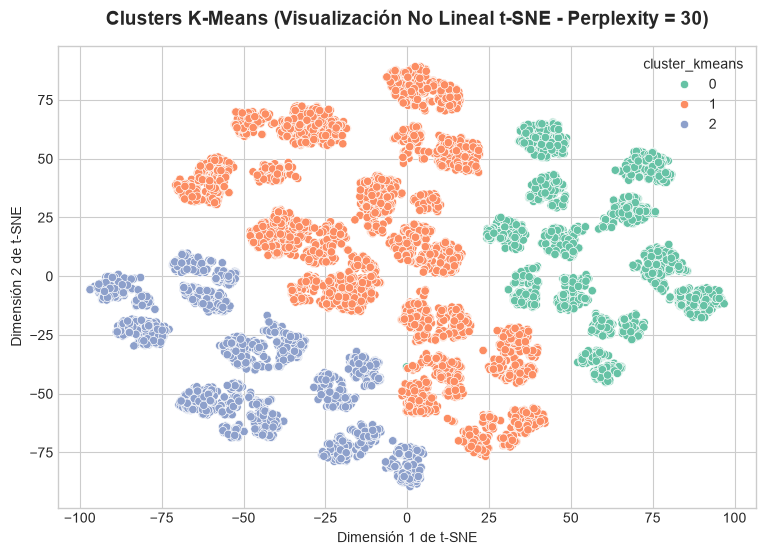

In [13]:
# 1. Instanciamos parametros y corremos t-SNE para la reducción de dimensionalidad a 2D
#1.1 Tomamos tiempo de ejecución para el entrenamiento de t-SNE
print("Ejecutando t-SNE para reducción de dimensionalidad a 2D...")

start_time_tsne = pd.Timestamp.now()  # Capturamos el tiempo de inicio

# 1.2 Parametros de t-SNE: n_components=2 para 2D, perplexity=30 (valor estándar), random_state=42 para reproducibilidad
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

end_time_tsne = pd.Timestamp.now()  # Capturamos el tiempo de finalización
execution_time_tsne = (end_time_tsne - start_time_tsne).total_seconds()
print(f"\n⏱️ Tiempo de ejecución para t-SNE: {execution_time_tsne:.2f} segundos")

# 2. Realizamos la grafica
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['cluster_kmeans'], palette='Set2')
plt.title('Clusters K-Means (Visualización No Lineal t-SNE - Perplexity = 30)')
plt.xlabel('Dimensión 1 de t-SNE')
plt.ylabel('Dimensión 2 de t-SNE')
plt.show()

### 💻 6. Tasa de Churn por Segmento

**Finalidad y Funcionalidad del Análisis de Churn por Segmento**
- **Propósito:** Validar el valor operativo del clustering de K-Means, comprobando si los grupos creados no solo se diferencian en sus características demográficas/financieras, sino también en su **comportamiento de abandono (Churn)**.
- **Funcionalidad de Negocio:** Permite pasar del análisis descriptivo a la **acción estratégica**. Identifica qué segmento del dataset representa la mayor tasa de churn, para que, podamos optimizar los recursos, dirigir campañas de retención prioritarias e hiperpersonalizadas hacia el grupo de mayor riesgo en lugar de aplicar medidas genéricas a todos los clientes.

### 📊 Análisis de la Tasa de Abandono (Churn) por Segmento
El análisis del comportamiento de abandono frente a la **media global (20.37%)** revela una clara concentración del riesgo en uno de los segmentos:

#### 💡 Puntos Clave
* **Cluster 0 (Segmento de Alto Riesgo):** Presenta la tasa de churn más crítica con un **32.44%** (814 abandono de 2,509 clientes), superando por más de 12 puntos porcentuales la media del banco. Requiere estrategias inmediatas de retención. Tecnicamente casi 1 de cada 3 clientes esta siendo churn.
* **Cluster 1 (Segmento Mayoritario y Estabilizado):** Es el grupo más numeroso (5,014 clientes) y mantiene una tasa de abandono baja del **16.15%**, situándose holgadamente por debajo del promedio global.
* **Cluster 2 (Segmento Conservador):** Muestra una tasa de Churn del **16.67%** (413 abandonos de 2,477 clientes), manteniendo un comportamiento muy alineado con el Cluster 1 y con un riesgo controlado.

Clientes Churn por Cluster (K-Means):
----------------------------------------------------------------------------------------------------


,cluster_kmeans,Churn_Rate,Churn_Count,Total
0,0,32.44,814,2509
1,1,16.15,810,5014
2,2,16.67,413,2477


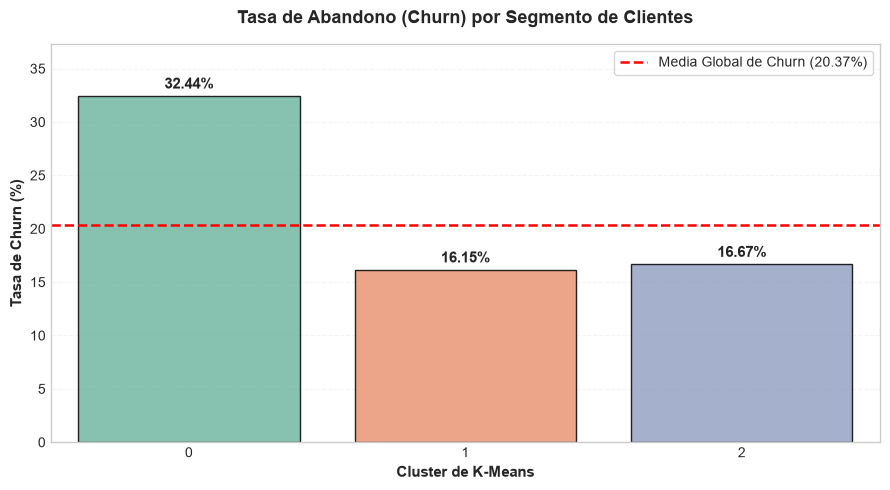

In [14]:
# 1. Agrupación y cálculo de métricas de Churn por cluster K-Means (datos reales)
churn_cluster = df.groupby('cluster_kmeans')['Exited'].agg(['mean', 'sum', 'count']) # Agrupamos por cluster y calculamos la media (tasa de churn), suma (cantidad de churn) y conteo (total de clientes)
churn_cluster.columns = ['Churn_Rate', 'Churn_Count', 'Total'] # Renombramos las columnas para mayor claridad al momento de imprimir
churn_cluster['Churn_Rate'] = (churn_cluster['Churn_Rate'] * 100).round(2) # Convertimos la tasa de churn a porcentaje y redondeamos a 2 decimal
churn_cluster = churn_cluster.reset_index() # Reiniciamos el índice para tener una columna 'cluster_kmeans' en lugar de un índice

#1.1 Imprimimos la tabla de Churn por cluster K-Means
print("Clientes Churn por Cluster (K-Means):")
print("-" * 100)
display(churn_cluster)

# 2. Configuración de la gráfica
plt.figure(figsize=(9, 5))
global_churn = df['Exited'].mean() * 100
ax = sns.barplot(
    data=churn_cluster,
    x='cluster_kmeans',
    y='Churn_Rate',
    palette='Set2',
    edgecolor='black',
    alpha=0.85
)

plt.axhline(
    y=global_churn, 
    color='red', 
    linestyle='--', 
    linewidth=1.8, 
    label=f'Media Global de Churn ({global_churn:.2f}%)'
)

# 2.1 Agregar etiquetas numéricas sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.2f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )
plt.xlabel('Cluster de K-Means', fontsize=11, fontweight='bold')
plt.ylabel('Tasa de Churn (%)', fontsize=11, fontweight='bold')
plt.title('Tasa de Abandono (Churn) por Segmento de Clientes', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.2, axis='y', linestyle='--')
plt.ylim(0, max(churn_cluster['Churn_Rate']) * 1.15)
plt.tight_layout()
plt.show()

### 💻 6.1 Analizar características de cada segmento - Tasa de Churn

### 👤 Perfiles de Clientes por Cluster (Segmentación K-Means)

1. **Cluster 0: Cliente Alemán de Alto Balance (Segmento Crítico / Riesgo Churn)**
   * **Demografía y Ubicación:** 100% ubicados en **Alemania** (`Geography_Germany = 1.0`). Edad promedio de ~40 años.
   * **Comportamiento Financiero:** Tienen el saldo promedio más alto con diferencia (**$119,730.12**).
   * **Riesgo:** Presentan la **tasa de Churn más alta (32.44%)**. A pesar de ser clientes de alto valor financiero, son los que más abandonan el banco.

2. **Cluster 1: Cliente Francés de Balance Moderado (Segmento Estable / Base)**
   * **Demografía y Ubicación:** 100% ubicados en **Francia** (`Germany=0`, `Spain=0`).
   * **Comportamiento Financiero:** Saldo medio de **$62,092.64** y salario estimado de ~$99,899.
   * **Riesgo:** Tasa de abandono baja (**16.15%**). Es el segmento más numeroso y estable de la entidad.

3. **Cluster 2: Cliente Español de Balance Moderado (Segmento Leal)**
   * **Demografía y Ubicación:** 100% ubicados en **España** (`Geography_Spain = 1.0`).
   * **Comportamiento Financiero:** Saldo medio de **$61,818.15**, similar al mercado francés.
   * **Riesgo:** Tasa de abandono baja (**16.67%**), manteniéndose holgadamente por debajo de la media global (20.37%).

Creando variables principales para ver el perfil demográfico y de comportamiento...
--- PERFIL COMPLETO POR CLUSTER ---


,Cluster 0,Cluster 1,Cluster 2
CreditScore,651.454,649.668,651.334
Gender,0.525,0.549,0.560
Age,39.772,38.512,38.891
Tenure,5.010,5.005,5.032
Balance,119730.116,62092.637,61818.148
NumOfProducts,1.520,1.531,1.539
HasCrCard,0.714,0.707,0.695
IsActiveMember,0.497,0.517,0.530
EstimatedSalary,101113.435,99899.181,99440.572
Exited,0.324,0.162,0.167


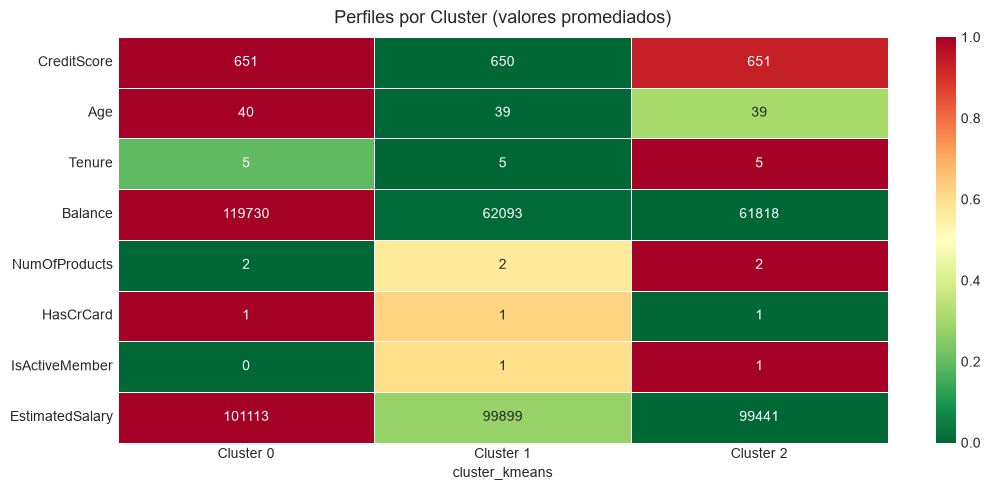

In [15]:
# 1. Calcular las métricas de Churn por cluster
print("Creando variables principales para ver el perfil demográfico y de comportamiento...")

churn_stats = df.groupby('cluster_kmeans')['Exited'].agg(
    Churn_Count='sum',
    Churn_Rate=lambda x: round(x.mean() * 100, 2)
).T

# 2. Cambiar nombres de columnas para que coincidan con perfil_clusters
churn_stats.columns = [f'Cluster {i}' for i in churn_stats.columns]

# 3. Creamos la lista de variables para el perfil de clientes por cluster
vars_perfil = [
'CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', ''
'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain'
]

perfil_clusters = df.groupby('cluster_kmeans')[vars_perfil].mean().round(3).T
perfil_clusters.columns = [f'Cluster {i}' for i in perfil_clusters.columns]

# 3. Unir (concatenar) las métricas de Churn con la tabla de perfiles que ya tenías
perfil_completo = pd.concat([perfil_clusters, churn_stats])

# 4. Mostrar la tabla final
print("--- PERFIL COMPLETO POR CLUSTER ---")
display(perfil_completo)
# Descargo libreria para manejar el escalado del heatmap
from sklearn.preprocessing import MinMaxScaler

# 5. Condiciones para gráfica Comparativa de Tasa de Churn por Cluster
vars_heatmap = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary',
]
perfil_reales = df.groupby('cluster_kmeans')[vars_heatmap].mean().T
perfil_reales.columns = [f'Cluster {i}' for i in perfil_reales.columns]

# 5.1. Escalar los valores por fila (entre 0 y 1) solo para definir la paleta de colores
scaler = MinMaxScaler()

# 5.2 Transponemos para escalar por variable (fila por fila)
perfil_escalado = pd.DataFrame(
    scaler.fit_transform(perfil_reales.T).T,
    index=perfil_reales.index,
    columns=perfil_reales.columns,
)

# 5.3 Crear el formato del texto en la gráfica
annot_matrix = perfil_reales.round(0).astype(int).astype(str)

# 6. Graficar el Heatmap
plt.figure(figsize=(11, 5))
sns.heatmap(
    perfil_escalado,  # Define los colores (de 0 a 1)
    annot=annot_matrix,  # Imprime los valores reales enteros
    fmt='',  # Formato de texto directo
    cmap='RdYlGn_r',  # Paleta de Rojo (alto) a Verde (bajo)
    linewidths=0.5,
    cbar_kws={'label': ''},
)
plt.title(
    'Perfiles por Cluster (valores promediados)',
    fontsize=13,
    fontweight='normal',
    pad=10,
)
plt.xlabel('cluster_kmeans', fontsize=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 💻 7. Features Derivadas de Clustering - De No Supervisado a Supervisado

***Breve Concepto***
Una feature derivada (o variable derivada) es una nueva columna o variable que se crea a partir de la manipulación, combinación o transformación de variables que ya existen en el dataset original. No es una información que se recolectó directamente "en bruto", sino el resultado de aplicar lógica de negocio, cálculos matemáticos o algoritmos de Machine Learning sobre los datos base.

- Ejemplo con Clustering: se puede crear la columna "is_high_risk_german_segment" combinando la geografía y el número de cluster asignado por K-Means.

La función principal de crear features derivadas es extraer y simplificar el conocimiento para facilitar el trabajo de los algoritmos de clasificación/predicción (como XGBoost, Random Forest o Regresión Logística).

***❗❗ USAREMOS LOS CLUSTERS DE K-MEANS PARA LA CREACIÓN DE ESTAS NUEVAS VARIABLES***

Rázones:
1. **Geometría y Estructura de los Datos**
* **K-Means:** diseñado para encontrar clusters esféricos o hiper-esféricos de tamaño relativamente similar. Al trabajar con variables socio-demográficas y financieras escaladas (edad, saldo, puntuación crediticia), la distribución de los clientes tiende a formar agrupaciones compactas alrededor de centros definidos. Como viasualizamos a lo largo de este avance.

* **DBSCAN:** Está diseñado para encontrar clusters de formas arbitrarias o complejas (como espirales o formas en "C") basados en la densidad de puntos en el espacio. Para éste dataset, el rendimiento no fue optimo, ya que en éste tipo de datos de clientes en tablas, rara vez existen este tipo de geometrías complejas.

2. **Sensibilidad a la Alta Dimensión y Escala**
* **DBSCAN:** Depende de una distancia fija (*Epsilon*) para definir vecindades; en espacios con muchas variables (especialmente tras aplicar One-Hot Encoding a países y género), la distancia entre puntos se vuelve casi homogénea, haciendo que DBSCAN clasifique a casi todos los clientes como un solo gran grupo o con mucho ruido/outliers (etiqueta -1).
* **K-Means:** Maneja mucho mejor los espacios continuos estandarizados y fuerza a que cada cliente pertenezca a un segmento usable para el negocio.

3. **Control del Número de Clusters para Uso Negocio**
* **K-Means:** Te permite definir de antemano el número de grupos (K) utilizando técnicas objetivas como el Método del Codo o el Coeficiente de Silueta. Esto es ideal para marketing, ya que las empresas necesitan un número manejable y fijo de segmentos para diseñar estrategias operativas.
* **DBSCAN:** No permite fijar el número de clusters. Dependiendo de los parámetros eps y min_samples, puede devolver 50 clusters pequeños o 1 solo cluster gigante, lo cual no es práctico para la segmentación de clientes.

### 🎯 Reordenamiento y Prioridad de Atencionalidad (`cluster_risk_priority`)

Se transformó la etiqueta nominal abstracta asignada por K-Means en una **escala ordinal de prioridad** basada en la tasa de Churn observada históricamente: Asignación de Prioridad: **{1: 0, 2: 1, 0: 2}**
1. * **`cluster_risk_priority = 0` (Menor Riesgo):** Corresponde al **Cluster 1** (Tasa de Churn ~16.15%). Segmento estable y numeroso.
2. * **`cluster_risk_priority = 1` (Riesgo Moderado):** Corresponde al **Cluster 2** (Tasa de Churn ~16.67%). Segmento de comportamiento medio.
3. * **`cluster_risk_priority = 2` (Mayor Riesgo / Máxima Prioridad):** Corresponde al **Cluster 0** (Tasa de Churn ~32.44%). Segmento crítico en Alemania con el mayor volumen de fugas.

#### 💡 Justificación Técnica y Operativa

1. **Optimización para Algoritmos de Aprendizaje Supervisado (en especial árboles) :**
   Al codificar los valores de manera ascendente (0 \rightarrow 1 \rightarrow 2) en directa concordancia con la probabilidad de abandono (Exited = 1), se crea una **relación monotónica positiva**. Esto permite que los nodos de decisión del algoritmo realicen cortes (*splits*) óptimos y más precisos con menor profundidad.

In [16]:
# 1. Calcular el ranking dinámico: Menor Riesgo = 0, Mayor Riesgo = N-1 (Monotónico positivo)
risk_order = (
    df.groupby('cluster_kmeans')['Exited']
    .mean()
    .sort_values(ascending=True)
    .index
)

risk_rank_map = {
    cluster_id: rank for rank, cluster_id in enumerate(risk_order)}

# 2. Crear la feature de prioridad (ideal para XGBoost y útil para Negocio)
df['cluster_risk_priority'] = df['cluster_kmeans'].map(
    risk_rank_map
)

# Imprimir la asignación
print("🎯 Asignación de Prioridad (0 = Menor Riesgo, 2 = Mayor Riesgo / Máxima Prioridad):")
print(risk_rank_map)

🎯 Asignación de Prioridad (0 = Menor Riesgo, 2 = Mayor Riesgo / Máxima Prioridad):
{1: 0, 2: 1, 0: 2}


## 📌 Conclusión General - Avance 3: Segmentación No Supervisada y Feature Engineering

### 1. Síntesis del Trabajo Realizado
En este Avance 3, exploramos y estructuramos en profundidad el espacio de datos de clientes mediante **técnicas de Aprendizaje No Supervisado**, **Reducción de Dimensionalidad** y **Generación de Características Derivadas** para fortalecer la capacidad predictiva sobre la tasa de abandono (*Churn*):

* **Evaluación de Algoritmos de Clustering (K-Means vs. DBSCAN):**
  * Mediante el **Método del Codo (*Elbow Method*)** y la evaluación del **Coeficiente de Silueta (*Silhouette Score*)**, se determinó de forma objetiva que **K = 3** representa la partición óptima para la estructura de nuestros datos escalados.
  * Se analizó de forma comparativa el algoritmo **DBSCAN** ("eps", "min\_samples"). Aunque demostró ser eficaz identificando observaciones atípicas (*outliers* / ruido), se optó por **K-Means** debido a la naturaleza compacta/esférica de las variables financieras escaladas y la necesidad operativa del negocio de contar con un número fijo y manejable de segmentos.

* **Reducción de Dimensionalidad y Visualización Espacial (PCA vs. t-SNE):**
  * Se implementó **PCA (Análisis de Componentes Principales)** para proyectar el espacio multidimensional en 2D y 3D, analizando la tasa de varianza explicada acumulada para verificar la representatividad gráfica.
  * Se empleó **t-SNE** como herramienta de visualización no lineal para explorar vecindades locales y confirmar si existía una separación natural evidente entre los grupos de *Churn* y retención.

### 2. Hallazgos Clave de Negocio (Perfiles de Clientes)
A través de la perfilación de centroides y mapas de calor (*Heatmaps*), se identificaron tres segmentos bien definidos:

1. **Cluster 0 — Segmento Crítico de Alto Riesgo (~32.44% Churn):**
   * **Perfil:** Clientes ubicados mayoritariamente en **Alemania**, con saldos bancarios elevados (`Balance`), bajo nivel de actividad (`IsActiveMember`) y menor retención de productos. 
   * **Impacto:** Constituyen la prioridad máxima para las estrategias de retención proactiva.

2. **Cluster 1 y Cluster 2 — Segmentos Estables (~16.15% y ~16.67% Churn):**
   * **Perfil:** Clientes con una relación bancaria sólida, mayor engagement o saldos promedio moderados/bajos.
   * **Impacto:** Representan la base operacional estable para campañas de fidelización cruzada (*cross-selling*).

### 3. Integración con el Modelado Supervisado (*Feature Engineering*)
La gran contribución de este avance fue transformar los resultados del clustering en **conocimiento directo para el modelo predictivo**:

* **Features Derivadas:** 
* **Reordenamiento Monotónico (`cluster_risk_priority`):** Se mapeó la pertenencia al cluster en una escala ordinal ($0 \rightarrow 1 \rightarrow 2$) en concordancia exacta con la tasa creciente de *Churn*. Esta codificación facilita a los modelos basados en árboles (**XGBoost**, Random Forest) realizar divisiones (*splits*) en los nodos de forma óptima y permite al negocio establecer **reglas automatizadas de atención prioritaria**.

### 💡 Conclusión Final
La combinación de segmentación no supervisada con técnicas supervisadas demuestra que el agrupamiento no solo sirve para describir al cliente, sino que **enriquece el espacio de variables**, permitiendo a modelos complejos como **XGBoost** capturar patrones no lineales con mayor precisión y entregar una herramienta 100% accionable para el área de Fidelización.

### ⚡MODELO DE PRUEBA XGBOOST OPTIMIZADO

Ejecutando GridSearchCV para XGBoost...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

📌 MÉTRICAS DE EVALUACIÓN XGBOOST HIPERPARAMETRIZADO
              precision    recall  f1-score   support

    No Churn     0.8816    0.9630    0.9205      1593
       Churn     0.7731    0.4939    0.6027       407

    accuracy                         0.8675      2000
   macro avg     0.8273    0.7284    0.7616      2000
weighted avg     0.8595    0.8675    0.8558      2000

Accuracy Score: 0.8675      | 86.75% 
Precision Score: 0.7731      | 77.31% 
Recall Score: 0.4939      | 49.39% 
F1-Score: 0.6027      | 60.27% 
ROC - AUC Score: 0.8651      | 86.51% 

----------------------------------------------------------------------------------------------------
             Feature_Name  Importance_Gain
5           NumOfProducts        29.658619
7          IsActiveMember        24.360775
2                     Age        22.586832
9       Geography_Germany        15.882449
1              

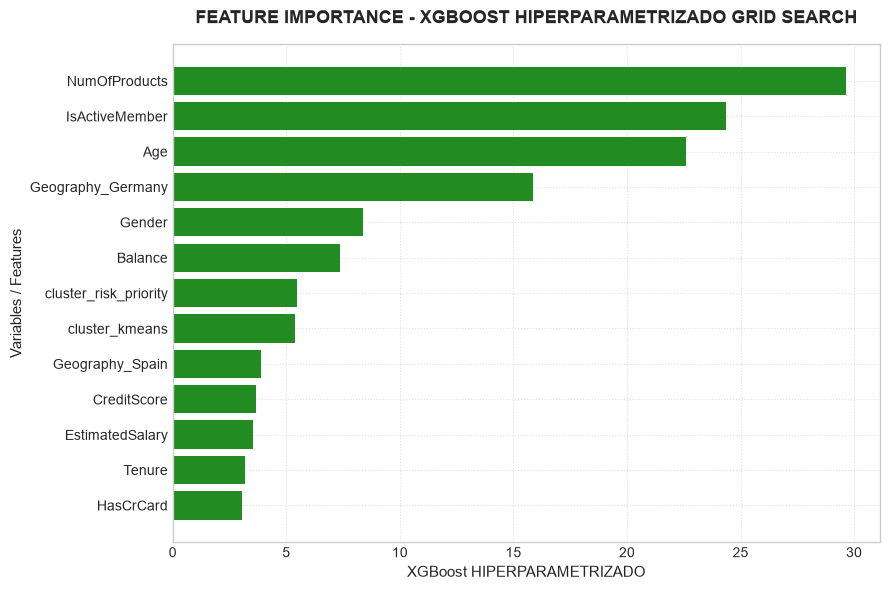

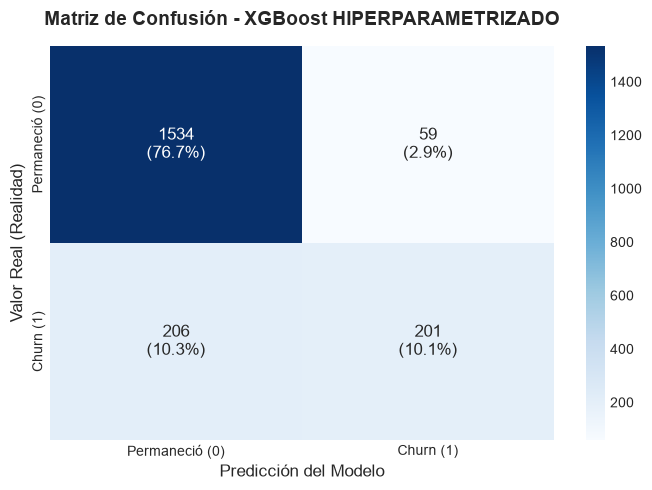

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST HIPERPARAMETRIZADO:
----------------------------------------------------------------------------------------------------
❗❗ Falsos Negativos   (FN):  206 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   59 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1534 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  201 (Clientes en churn detectados a tiempo)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    KFold,
    TimeSeriesSplit,
    cross_validate,
)

from sklearn.metrics import (
    average_precision_score,
    accuracy_score,                    
    auc,
    roc_auc_score,
    classification_report,             
    f1_score,                          
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay, 
    confusion_matrix
)

# 1. Definir Features (X) e Identificar el Target (Y)
x = df.drop(columns=['Exited', 'kmeans_cluster_label','cluster_dbscan'], errors='ignore')
Y = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(
    x, Y,
    test_size=0.2,      # 20% para test
    random_state=42,    # Reproducibilidad
    stratify=Y          # Mantener proporción de clase
)

scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Malla de Hiperparámetros
param_grid_xgb = {
    'n_estimators': [100, 200, 300],    # Cantidad de árboles
    'max_depth': [3, 5, 7],             # Profundidad máxima
    'learning_rate': [0.01, 0.1, 0.2],  # Tasa de aprendizaje
    'subsample': [0.8, 1.0],            # Submuestra de filas por árbol
    'colsample_bytree': [0.8, 1.0],     # Submuestra de columnas por árbol
    'reg_alpha': [0, 0.1],              # L1 regularization
    'reg_lambda': [1, 10]               # L2 regularization
}

# 4. Buscador de Hiperparámetros Optimizado (GridSearchCV)
xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_grid_xgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',  # Métrica de optimización
    n_jobs=-1,          # Usa todos los CPU
    verbose=1
)

print("Ejecutando GridSearchCV para XGBoost...")
xgb_grid.fit(x_train_scaled, y_train)

# Extraer el mejor modelo
xgb_best_grid = xgb_grid.best_estimator_
y_pred_xgb_best = xgb_best_grid.predict(x_test_scaled)
y_pred_proba_xgb_best = xgb_best_grid.predict_proba(x_test_scaled)[:, 1]

# 7. Métricas de Evaluación
accuracy_xgb_best = accuracy_score(y_test, y_pred_xgb_best)
precision_xgb_best = precision_score(y_test, y_pred_xgb_best, pos_label=1)
recall_xgb_best = recall_score(y_test, y_pred_xgb_best, pos_label=1)
f1_xgb_best = f1_score(y_test, y_pred_xgb_best, pos_label=1)

print("\n📌 MÉTRICAS DE EVALUACIÓN XGBOOST HIPERPARAMETRIZADO")
print(classification_report(y_test, y_pred_xgb_best, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy Score: {accuracy_xgb_best:.4f}      | {accuracy_xgb_best*100:.2f}% ")
print(f"Precision Score: {precision_xgb_best:.4f}      | {precision_xgb_best*100:.2f}% ")
print(f"Recall Score: {recall_xgb_best:.4f}      | {recall_xgb_best*100:.2f}% ")
print(f"F1-Score: {f1_xgb_best:.4f}      | {f1_xgb_best*100:.2f}% ")

# 7.2 Curva ROC - AUC
fpr_xgb_best, tpr_xgb_best, thresholds_xgb_best = roc_curve(y_test, y_pred_proba_xgb_best)
roc_auc_xgb_best = auc(fpr_xgb_best, tpr_xgb_best)

print(f"ROC - AUC Score: {roc_auc_xgb_best:.4f}      | {roc_auc_xgb_best*100:.2f}% \n")
print("-" * 100)

# 8. Feature Importance con método Gain
importance_gain = xgb_best_grid.get_booster().get_score(importance_type='gain')
xgb_gain_feature_df = pd.DataFrame({
    'Feature': list(importance_gain.keys()),
    'Importance_Gain': list(importance_gain.values())
}).sort_values('Importance_Gain', ascending=False) 

features_name = x_train.columns.tolist()
xgb_gain_feature_df['Feature_Name'] = xgb_gain_feature_df['Feature'].apply(
    lambda x: features_name[int(x[1:])] if x[0] == 'f' else x 
)

print(xgb_gain_feature_df[['Feature_Name','Importance_Gain']].head(10))

# 8.3 Gráfica Feature Importance
plt.figure(figsize=(9, 6))
plt.barh(xgb_gain_feature_df['Feature_Name'], xgb_gain_feature_df['Importance_Gain'], color='forestgreen')
plt.xlabel('XGBoost HIPERPARAMETRIZADO', fontsize=11)
plt.ylabel('Variables / Features', fontsize=11)
plt.title('FEATURE IMPORTANCE - XGBOOST HIPERPARAMETRIZADO GRID SEARCH', fontsize=13, pad=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 9. Matriz de Confusión
best_xgboost_mc = confusion_matrix(y_test, y_pred_xgb_best)

labels_xgboost_best = [f'{val_3}\n({pctj_3:.1f}%)' for val_3, pctj_3 in zip(
    best_xgboost_mc.flatten(), best_xgboost_mc.flatten() / best_xgboost_mc.sum() * 100
)]
labels_xgboost_best = np.array(labels_xgboost_best).reshape(2, 2)

plt.figure(figsize=(7, 5))
sns.heatmap(
    best_xgboost_mc,
    annot=labels_xgboost_best,
    fmt='',
    cmap='Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - XGBoost HIPERPARAMETRIZADO', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# Desglose de la Matriz
tn_xgb_best, fp_xgb_best, fn_xgb_best, tp_xgb_best = best_xgboost_mc.ravel()

print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST HIPERPARAMETRIZADO:")
print("-" * 100)
print(f"❗❗ Falsos Negativos   (FN): {fn_xgb_best:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_xgb_best:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_xgb_best:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_xgb_best:4d} (Clientes en churn detectados a tiempo)")